# Setup

## Imports

In [1]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Add the project root (the first parent folder containing src/) to sys.path
root_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loading import load_csv_data, load_dataset_config, parse_preprocessing_config
from src.preprocessing import filter_doublets, normalize_by_library_size, log_transform, normalize_with_pearson
from src.preprocessing.pipeline import run_filtering_pipeline
from src.visualization import (
    plot_qc_overview,
    plot_gene_set_qc,
    plot_gene_max_count_distribution,
    plot_normalization_comparison,
    plot_log_transform_comparison,
)

## Data Loading

In [21]:
from src.data_loading import load_csv_data

DATA_PATH = root_path / 'data/E-MTAB-3321/raw/E-MTAB-3321.csv.gz'
raw_data = load_csv_data(DATA_PATH)

raw_data

,ENSMUSG00000000001,ENSMUSG00000000003,ENSMUSG00000000028,ENSMUSG00000000031,ENSMUSG00000000037,ENSMUSG00000000049,ENSMUSG00000000056,ENSMUSG00000000058,ENSMUSG00000000078,ENSMUSG00000000085,...,ERCC-00157,ERCC-00158,ERCC-00160,ERCC-00162,ERCC-00163,ERCC-00164,ERCC-00165,ERCC-00168,ERCC-00170,ERCC-00171
2cell_1_A,165,0,722,0,58,0,12,0,0,10,...,0,1,1,0,0,0,0,0,0,23
2cell_1_B,79,0,547,0,33,0,3,0,0,1,...,1,0,0,0,0,0,0,0,0,21
2cell_2_A,124,0,481,0,22,0,7,0,0,31,...,0,0,0,0,0,0,0,0,0,11
2cell_2_B,41,0,219,0,34,0,9,0,0,38,...,0,0,0,0,0,0,1,0,0,17
2cell_3_A,107,0,808,0,68,0,20,0,0,64,...,0,0,0,0,0,0,0,0,0,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EM_4cell_6_D,63,0,162,0,0,0,3,0,0,15,...,5,0,5,9,2,0,7,0,28,281
ME_4cell_6_A,109,0,186,0,12,0,11,0,0,37,...,0,0,5,10,7,0,7,0,0,406
ME_4cell_6_B,82,0,284,0,13,0,0,0,0,7,...,5,0,9,26,6,0,0,0,8,573
ME_4cell_6_C,33,0,409,0,0,0,0,0,6,4,...,0,0,1,20,0,0,0,0,2,428


## Dataset config

In [4]:
DATASET_DIR = root_path / 'data/E-MTAB-3321'

dataset_config = load_dataset_config(DATASET_DIR)
SPECIES = dataset_config["species"]
preprocessing_config = parse_preprocessing_config(dataset_config)

preprocessing_config

PreprocessingConfig(mito_threshold=0.05, rrna_threshold=0.05, apoptosis_threshold=0.05, min_gene_max_count=2)

# Quality Control (Cell Filtering)

All QC metrics are computed on the raw matrix, before any gene filtering, so each one reflects the full count depth of the cell.
The plots below follow Luecken & Theis (2019), Fig. 2. Pass candidate thresholds to draw them on the plots, then set the chosen values in `data/E-MTAB-3321/config.yaml`.

## Count depth and genes per cell

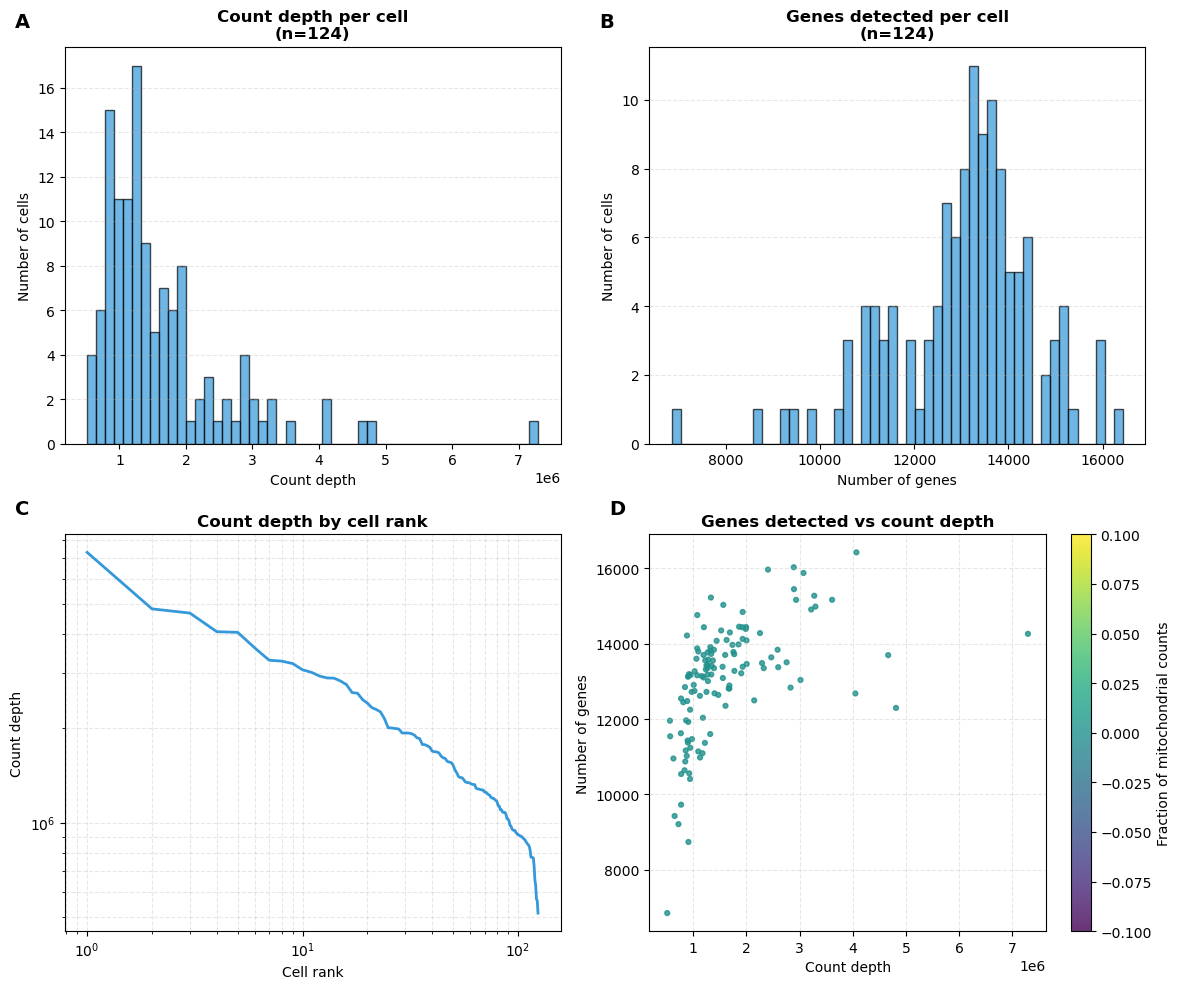

In [5]:
plot_qc_overview(raw_data)

Re-run with candidate thresholds, e.g. `plot_qc_overview(raw_data, count_threshold=..., gene_threshold=...)`.

## Mitochondrial, rRNA and apoptosis fractions

Each panel plots the fraction of counts from one gene set against count depth, with the threshold from `config.yaml`. Red cells are above the threshold and are removed by that filter.
If the red cells are also the low-count ones, they are likely damaged; high fractions across all count depths may be biology.

This dataset uses Ensembl gene IDs (`ENSMUSG...`), while the gene sets use gene symbols (`mt-Co1`, `Rn5s`, `Casp3`, ...), so a panel shows "0 genes found" when nothing matches and that filter has no effect.

In [ ]:
plot_gene_set_qc(raw_data, SPECIES, preprocessing_config)

## Apply filters

Runs the same filtering as the benchmark pipeline (cell QC on the raw matrix, then the gene filter), using the thresholds from `config.yaml`.

In [10]:
clean_data = run_filtering_pipeline(raw_data, config=preprocessing_config, species=SPECIES)

clean_data.shape

(124, 25507)

# Gene Filtering

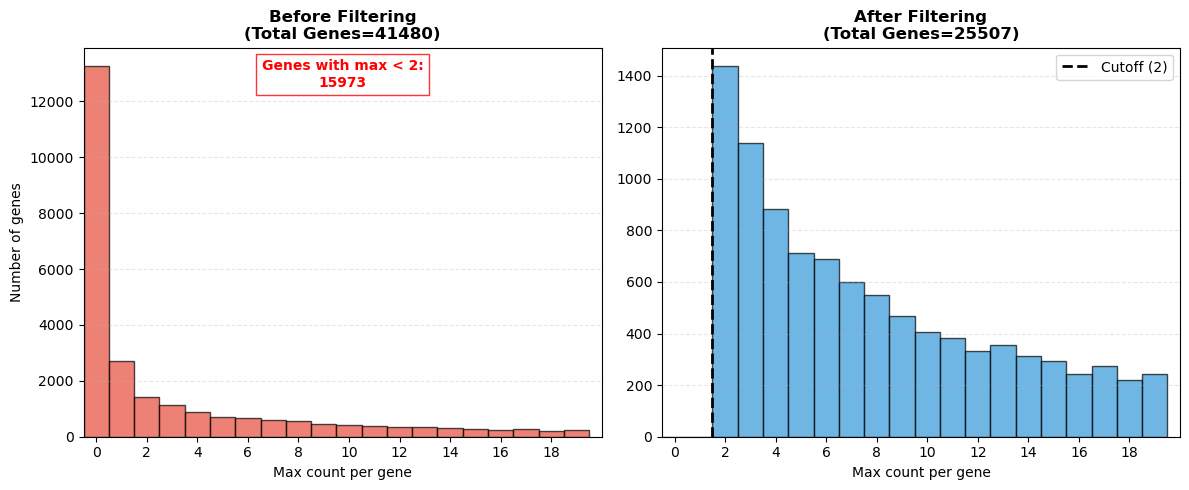

In [11]:
plot_gene_max_count_distribution(raw_data, clean_data, x_limit=20)

By filtering 15,973 genes that consist primarily of zeros or ones, the dataset is reduced from 41,480 to 25,507 genes. The resulting histograms visualize this shift: the "Before" plot is dominated by a huge peak of low-expression genes, while the "After" plot shows a more even distribution (long-tail effect removed).

## Doublets

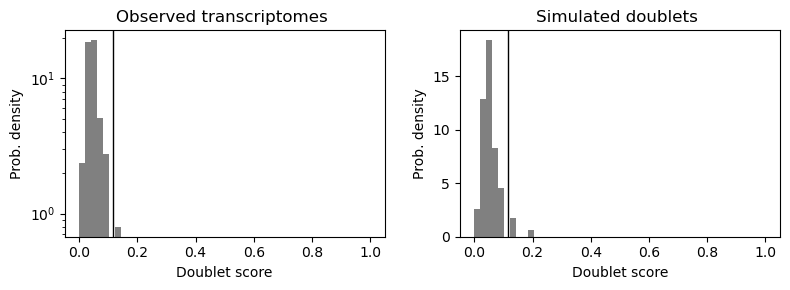

In [12]:
no_doublets_data = filter_doublets(clean_data)

# Normalization

## logCPM

### Normalize by library size

In [13]:
normalized_data = normalize_by_library_size(no_doublets_data)

normalized_data.shape

(122, 25507)

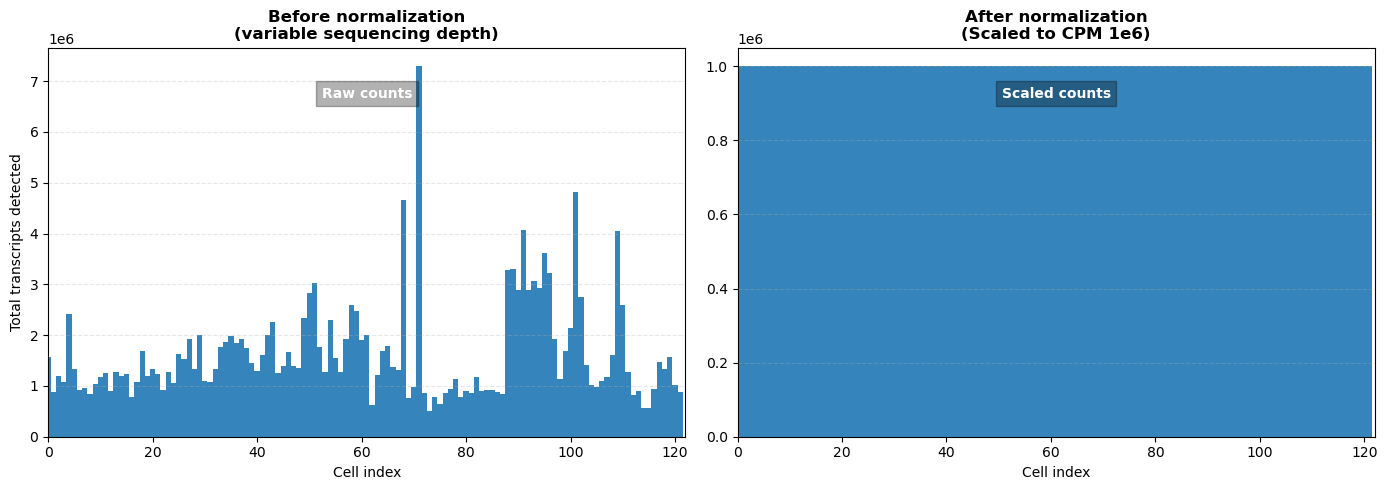

In [14]:
plot_normalization_comparison(no_doublets_data, normalized_data, n_cells=122)

### Log Transform

In [15]:
logged_data = log_transform(normalized_data)

logged_data.shape

(122, 25507)

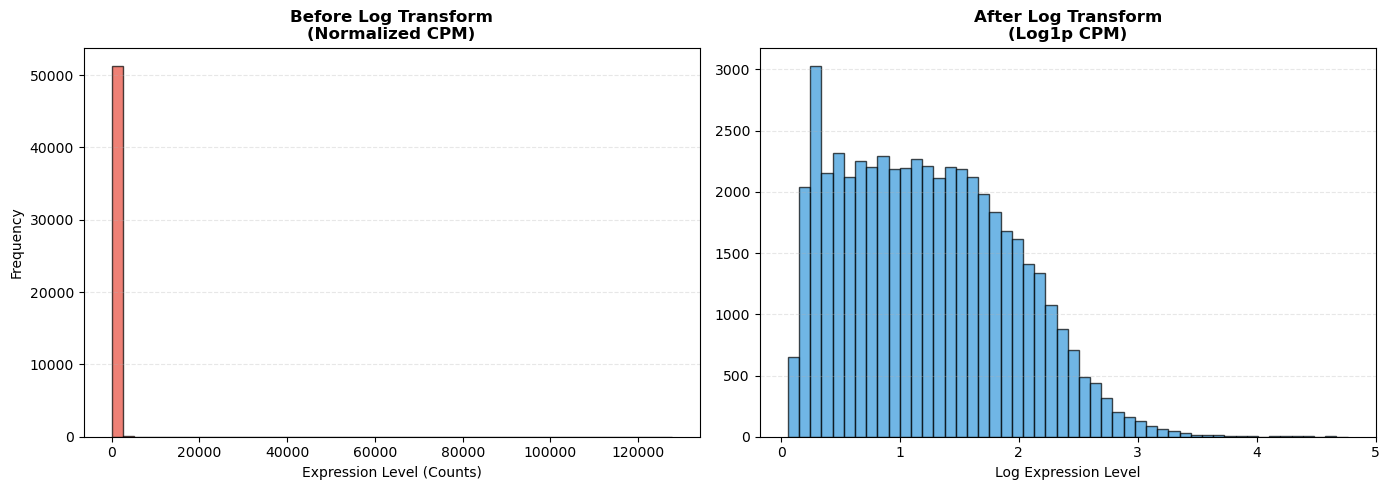

In [16]:
plot_log_transform_comparison(normalized_data, logged_data)

## Pearson residuals

In [17]:
pearsons_data = normalize_with_pearson(no_doublets_data)

pearsons_data.shape

/opt/anaconda3/envs/scrna-seq-clustering/lib/python3.14/site-packages/scanpy/experimental/pp/_normalization.py:66: RuntimeWarning: invalid value encountered in divide
  residuals = diff / np.sqrt(mu + mu**2 / theta)


(122, 25507)

In [18]:
pearsons_data.head()

,ENSMUSG00000000001,ENSMUSG00000000028,ENSMUSG00000000037,ENSMUSG00000000049,ENSMUSG00000000056,ENSMUSG00000000058,ENSMUSG00000000078,ENSMUSG00000000085,ENSMUSG00000000088,ENSMUSG00000000093,...,ERCC-00154,ERCC-00157,ERCC-00158,ERCC-00160,ERCC-00162,ERCC-00163,ERCC-00165,ERCC-00168,ERCC-00170,ERCC-00171
2cell_1_A,2.568837,11.024777,7.556910,-0.414487,1.299648,-2.052101,-3.155853,-1.524686,3.146389,-0.654519,...,-0.812725,-1.323737,1.931658,-0.876107,-3.339857,-1.652746,-2.839378,-0.197730,-1.286087,-8.711880
2cell_1_B,0.910488,11.045361,5.976033,-0.311447,-0.727284,-1.555721,-2.423615,-2.626570,4.401990,-0.492083,...,-0.611336,-0.006192,-0.318440,-1.146865,-2.571937,-1.248871,-2.171205,-0.148532,-0.969510,-7.957231
2cell_2_A,2.215578,8.130668,1.475128,-0.363177,0.291288,-1.806578,-2.797220,4.767630,1.318158,-0.573667,...,-0.712522,-1.162009,-0.371328,-1.334430,-2.964534,-1.452483,-2.511043,-0.173226,-1.128830,-8.654337
2cell_2_B,-3.476517,-0.019448,4.966522,-0.343941,1.395891,-1.713664,-2.659646,7.387451,-2.530427,-0.543337,...,-0.674913,-1.101154,-0.351662,-1.264828,-2.820146,-1.376957,-1.990344,-0.164043,-1.069671,-8.371253
2cell_3_A,-3.487121,5.919905,5.688301,-0.513393,1.998317,-2.514747,-3.810403,6.736458,1.406413,-0.810146,...,-1.005346,-1.632721,-0.524900,-1.871016,-4.020372,-2.033252,-3.444946,-0.245000,-1.586698,-8.967753
